## 目标与运行方法

下载完整 `.ipynb`，在 VibeIt Studio 文件浏览器中使用 **+ → Import from Files** 导入并打开。按从上到下的顺序运行代码单元；阅读模式中的图表是已保存的真实运行输出。重新运行会从内嵌数据计算结果。

本课适合具备 Python 基础的本科生。先阅读每一步的方法与图注，再修改参数。AI 练习为可选部分，不需要 AI 账号即可完成核心课程。数据写在 notebook metadata 中，不需要另下载数据文件。请保持 notebook 已保存到当前工作文件夹。

学习任务是理解本课的研究问题、执行透明的计算、校验结果，并说明结论的边界。

## 环境与参数

In [1]:
from pathlib import Path
import base64, gzip, hashlib, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from IPython.display import display as _display
def display(value):
    if isinstance(value,pd.DataFrame):
        table=value.to_html(max_rows=12,escape=True)
        style="<style>.vibeit-readable-table{max-width:100%;overflow-x:auto}.vibeit-readable-table table{width:max-content;max-width:none;border-collapse:collapse}.vibeit-readable-table td,.vibeit-readable-table th{white-space:nowrap!important;word-break:normal!important;overflow-wrap:normal!important}</style>"
        return _display(HTML(style+'<div class="vibeit-readable-table">'+table+'</div>'))
    return _display(value)
RECIPE_ID='en05-rc-circuit'
OUTPUT_DIR=Path.cwd()/"results"/RECIPE_ID
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.spines.top":False,"axes.spines.right":False,
                      "axes.prop_cycle":plt.cycler(color=["#18785f","#416aa6","#bc6541","#9974a5"])})
print("Python:",platform.python_version(),"; NumPy:",np.__version__,"; Pandas:",pd.__version__)
print("Working folder:",Path.cwd())
print("Core data mode: embedded snapshot; no network requests")


Python: 3.13.13 ; NumPy: 2.5.3 ; Pandas: 3.0.6
Working folder: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads
Core data mode: embedded snapshot; no network requests


### 读取内嵌快照

下面的加载函数按课程 ID 与 SHA-256 在当前文件夹定位本 notebook，解压后再次校验。文件改名不影响匹配。若找不到数据，确认当前工作目录与文件位置；不要用编造的数据替换它。metadata 随 `.ipynb` 保存及导出，复制代码到单独 `.py` 不会自动复制数据。

In [2]:
def load_snapshot(recipe_id, expected_sha256, snapshot_key):
    """Read embedded data from this notebook, including a renamed copy."""
    for path in sorted(Path.cwd().glob("*.ipynb")):
        try:
            notebook = json.loads(path.read_text(encoding="utf-8"))
            metadata = notebook.get("metadata", {}).get("vibeit_cookbook", {})
            blob = metadata.get("snapshots", {}).get(snapshot_key)
            if metadata.get("recipe_id") != recipe_id or not blob:
                continue
            if blob.get("sha256") != expected_sha256:
                continue
            raw = gzip.decompress(base64.b64decode(blob["gzip_base64"], validate=True))
            if hashlib.sha256(raw).hexdigest() != expected_sha256:
                raise ValueError("Embedded snapshot checksum mismatch: " + snapshot_key)
            return json.loads(raw)
        except (OSError, json.JSONDecodeError):
            continue
    raise FileNotFoundError(
        "Save/open the complete .ipynb in the active working folder. "
        "The embedded snapshot could not be located for " + recipe_id)

SNAPSHOT_HASHES={'models': '48fd2e6e706650fe2ee0c0ad80b6d794a546a1dec78dd9d370ac09db3cc3adbf'}
def snapshot(key):
    return load_snapshot(RECIPE_ID,SNAPSHOT_HASHES[key],key)
print("Embedded snapshots:",list(SNAPSHOT_HASHES))


Embedded snapshots: ['models']


### 方法函数

本课所需函数的完整代码就在下面。它们只使用已列出的预装包与标准库，运行时不会导入任何 cookbook 辅助模块。先检查输入约束和返回值；如果修改算法，后面的校验也需要继续通过。

In [3]:
def rc_step_response(resistance_ohm,capacitance_F,input_voltage_V,steps_per_tau=20,duration_tau=5):
    if resistance_ohm<=0 or capacitance_F<=0 or steps_per_tau<1 or duration_tau<=0:
        raise ValueError('Positive R/C and valid sampling settings are required')
    tau=resistance_ohm*capacitance_F;count=int(np.ceil(duration_tau*steps_per_tau))
    time=np.arange(count+1)*tau/steps_per_tau;voltage=np.zeros(count+1);dt=time[1]-time[0]
    for j in range(count):voltage[j+1]=voltage[j]+dt*(input_voltage_V-voltage[j])/tau
    exact=input_voltage_V*(-np.expm1(-time/tau))
    return dict(t=time,numerical_voltage=voltage,analytic_voltage=exact,tau_s=tau,step_s=dt)

print("Method ready: rc_step_response")


Method ready: rc_step_response


### 数据与模型边界

建筑记录包含来源中单栋建筑的真实十分钟能耗及环境观测。机场天气字段含来源插值，不是同位置校准参考。梁、电路和 PID 例子是明确的数值设计模型；计算响应不能证明硬件性能或实际验收。

## 分步分析

### 1. 比较解析与显式暂态响应

名义 tau=R·C，单位秒。显式 Euler 采用 dt=tau/20，解析阶跃为 Vin(1−exp(−t/tau))。这些是模型电压，不是示波器测量。

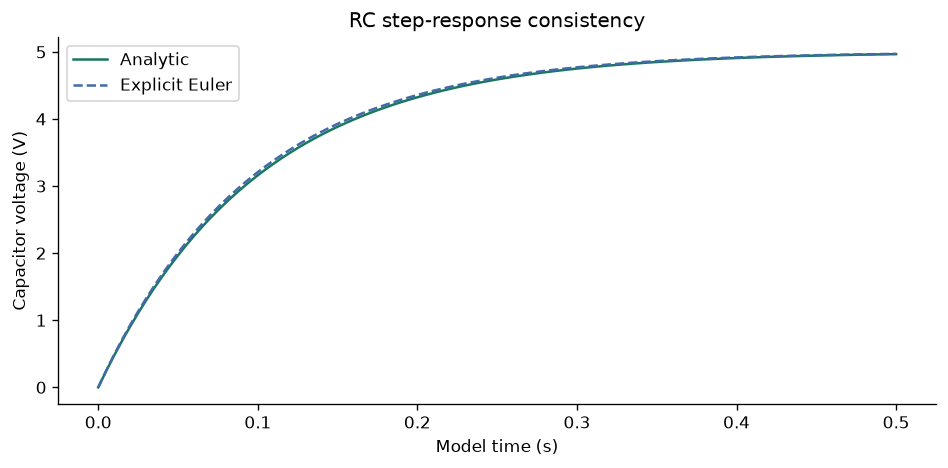

In [4]:
models=snapshot("models");p=models["circuit"]
solution=rc_step_response(p["resistance_ohm"],p["capacitance_F"],p["input_voltage_V"])
fig,ax=plt.subplots(figsize=(8,4));ax.plot(solution["t"],solution["analytic_voltage"],label="Analytic")
ax.plot(solution["t"],solution["numerical_voltage"],"--",label="Explicit Euler")
ax.set(xlabel="Model time (s)",ylabel="Capacitor voltage (V)",title="RC step-response consistency");ax.legend();plt.tight_layout();plt.show()


### 2. 以 Hz 单位解读增益及相位

传递响应为 1/(1+j2pi f RC)，角频率等于 2pi f。截止幅度为 1/sqrt(2)，约 −3.01 dB。相位使用度，模型未测量寄生元件。

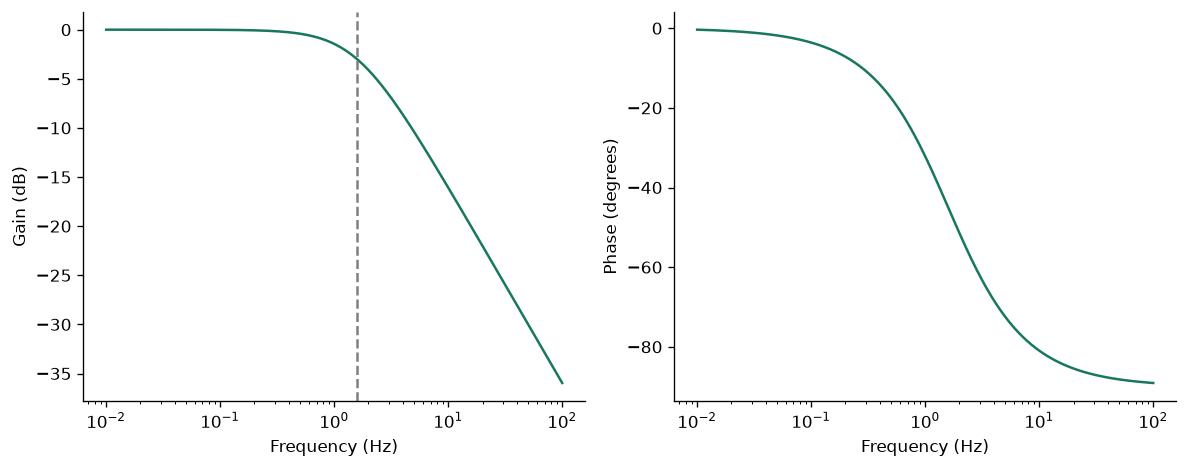

Nominal tau (s): 0.1 ; cutoff (Hz): 1.5915494309189535


In [5]:
tau=solution["tau_s"];frequency=np.geomspace(.01,100,501);response=1/(1+1j*2*np.pi*frequency*tau)
cutoff=1/(2*np.pi*tau)
fig,axes=plt.subplots(1,2,figsize=(10,4));axes[0].semilogx(frequency,20*np.log10(abs(response)))
axes[0].axvline(cutoff,color="gray",linestyle="--");axes[0].set(xlabel="Frequency (Hz)",ylabel="Gain (dB)")
axes[1].semilogx(frequency,np.angle(response,deg=True));axes[1].set(xlabel="Frequency (Hz)",ylabel="Phase (degrees)")
plt.tight_layout();plt.show();print("Nominal tau (s):",tau,"; cutoff (Hz):",cutoff)


### 3. 区分容差边界与概率假设

此 Monte Carlo 练习明确假设 R、C 独立均匀分布于 ±5%。真实容差规格是边界，不证明分布或独立性。图示模拟 tau，不是实测批次统计。

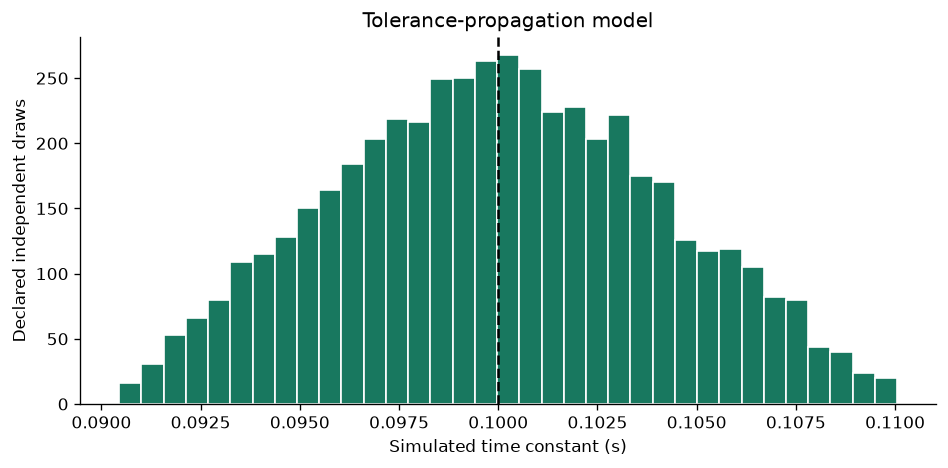

In [6]:
rng=np.random.default_rng(models["seed"]);tolerance=p["tolerance_fraction"]
resistance=p["resistance_ohm"]*rng.uniform(1-tolerance,1+tolerance,5000)
capacitance=p["capacitance_F"]*rng.uniform(1-tolerance,1+tolerance,5000);drawn_tau=resistance*capacitance
fig,ax=plt.subplots(figsize=(8,4));ax.hist(drawn_tau,bins=35,edgecolor="white");ax.axvline(tau,color="black",linestyle="--")
ax.set(xlabel="Simulated time constant (s)",ylabel="Declared independent draws",title="Tolerance-propagation model");plt.tight_layout();plt.show()


### 4. 检查极限并导出单位和假设

核对一时间常数的解析电压、截止幅度及容差范围。保存全部输入和假定分布；数值误差与模拟元件变异是不同量。

In [7]:
index=int(np.argmin(abs(solution["t"]-tau)))
assert np.isclose(solution["analytic_voltage"][index],p["input_voltage_V"]*(1-np.exp(-1)))
assert np.isclose(abs(1/(1+1j*2*np.pi*cutoff*tau)),1/np.sqrt(2))
assert drawn_tau.min()>=tau*(1-tolerance)**2 and drawn_tau.max()<=tau*(1+tolerance)**2
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
pd.DataFrame({"time_s":solution["t"],"analytic_voltage_V":solution["analytic_voltage"],"Euler_voltage_V":solution["numerical_voltage"]}).to_csv(OUTPUT_DIR/"rc-transient.csv",index=False)
pd.DataFrame({"frequency_Hz":frequency,"gain_dB":20*np.log10(abs(response)),"phase_degrees":np.angle(response,deg=True)}).to_csv(OUTPUT_DIR/"rc-frequency-response.csv",index=False)
(OUTPUT_DIR/"tolerance-assumptions.json").write_text(json.dumps({**p,"seed":models["seed"],"distribution":"independent uniform tolerance ranges; assumed, not inferred"},indent=2))
print("Circuit reference and bound checks passed; exports:",OUTPUT_DIR)


Circuit reference and bound checks passed; exports: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads/results/en05-rc-circuit


## 自主练习与参考答案

1. 解释 RC 及截止频率的单位。
2. 为何容差边界不是概率分布？

**参考解释。** RC 的单位为秒，1/(2pi RC) 为 Hz。制造边界本身不证明均匀性、独立性或经验区间。

先保留当前 notebook 副本，再修改参数。把新图与原图一起比较，并记录改变了哪些输入、哪些计算和哪些结论。

## 可选的 AI 编程练习

在 VibeIt 的 Coding Agent 中打开当前 notebook，先让助手阅读相关单元。核心课程不依赖 AI 服务；服务可用性与账号设置以应用帮助中心为准。

**提示词 1**

> 仅用 NumPy、Matplotlib 比较每 tau 十、二十、八十步，画相对解析解的实际误差。

**提示词 2**

> 使用同样的包比较独立均匀与明确标记的相关容差模拟。

**人工验收。** 解析极限、−3 dB 截止及单位一致，保存所有模拟分布假设。

检查修改后的源代码，再手动运行受影响单元及后续校验。要求助手解释修改的目的、使用的包和数据来源，并用实际输出核对解释。

## 可选联网扩展

默认关闭下面的联网操作。它只显示数据库版本及快照来源，不会替换核心数据。若要重新获取数据，应另存一个实验版本并记录新的 URL、数据库版本、获取日期与 SHA-256；新版结果需要重新执行和核验。

In [8]:
RUN_ONLINE_UPDATE=False
if RUN_ONLINE_UPDATE:
    import requests
    try:
        response=requests.get('https://docs.scipy.org/doc/scipy/tutorial/linalg.html',timeout=20)
        response.raise_for_status()
        print("Source:",response.url)
        print(response.text[:700])
    except requests.RequestException as error:
        print("Online extension unavailable:",type(error).__name__,str(error)[:160])
else:
    print("Online extension skipped; embedded core data unchanged")


Online extension skipped; embedded core data unchanged


## 来源、快照与下一步

- [IAPWS saturation reference release](https://iapws.org/public/documents/6dGkr/Supp-sat.pdf) — IAPWS SR1-86(1992): unrestricted publication allowed in all countries (cover page); retrieved 2026-10-09. SHA-256 `a10d38d73339b0713c86cfac88f9adcba137202167ccdfa1cd58238c438361d7`.
  Reference equations and numerical coefficients transcribed from release pages 2–3; pedagogical model values are not new experiments.

- [Authored numerical teaching model parameters](https://github.com/zhiluo20/vibeit/blob/main/cookbook-src/freeze_subject_data.py) — Original teaching parameters/code MIT; reference equation coefficients attributed to IAPWS SR1-86(1992); retrieved 2026-10-09. SHA-256 `4350c4305a83c772fa295a8be0ef86a247f2bfaae930a081720d3cd0c753abe0`.
  Declared parameters and seed; generated trajectories and calibration observations must be labelled simulated.


**下一步。** 在保留本课的数据检查、参数记录和结果校验之后，将相同方法用于自己的公开或已获授权数据。记录研究设计与方法限制，不把示例结果当成新实验的验证。完整数据许可与生成说明见 cookbook 网页。